# Confidence-Coloured Text — Mistral-Nemo Post-Correction

Each word in the corrected transcription is rendered in a grey shade  
determined by its per-word **WER confidence** from the TrOCR model:

| Confidence | Meaning | Colour |
|---|---|---|
| 1.0 | model certain | **black** |
| 0.5 | uncertain | grey |
| 0.0 | very uncertain | white (invisible) |

**Post-correction method:** Mistral-Nemo 12B running locally via Ollama  
(compare with Alex's Qwen method in `post_correction_full_test_v2_Alex.ipynb`)

**Source of confidence scores:** geometric mean of per-token log-probabilities  
stored in `data/confidence/<page_id>.txt` (computed by TrOCR with `output_scores=True`).

**Word alignment:** `difflib.SequenceMatcher` maps corrected-transcription words  
to their original confidence scores. Mistral-substituted words inherit the  
confidence of the original low-confidence word they replaced.

**Output:**  
- `data/mistral_confidence_coloured_text.html` — viewable in any browser  
- `data/mistral_confidence_distribution.png` — histogram + CDF  
- `data/mistral_corrected_transcriptions/` — one `.txt` per page

# Step 1 & 2: imports and paths

In [9]:
import difflib
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

# ── Input: confidence files ───────────────────────────────────────────
CONF_DIR = REPO_ROOT / 'data' / 'confidence'

# ── Input: your corrected txt files ──────────────────────────────────
CORRECTED_DIR = REPO_ROOT / 'mistral_corrected_transcriptions'

# ── Output ────────────────────────────────────────────────────────────
OUTPUT_HTML = REPO_ROOT / 'data' / 'mistral_confidence_coloured_text.html'
OUTPUT_PNG  = REPO_ROOT / 'data' / 'mistral_confidence_distribution.png'

DEFAULT_CONF = 0.5

def sort_key(p: Path):
    m = re.match(r'B(\d+)_P(\d+)', p.stem)
    return (int(m.group(1)), int(m.group(2))) if m else (99, 9999)

def normalise_page_id(stem: str) -> str:
    return re.sub(r'_P_(\d+)', r'_P\1', stem)

# Confidence files
conf_files = {p.stem: p for p in CONF_DIR.glob('*.txt')}

# Corrected files — your new format has no subfolders, no === header
corr_files_mistral = {
    normalise_page_id(p.stem): p
    for p in CORRECTED_DIR.rglob('*.txt')
}

page_ids = sorted(
    conf_files.keys() & corr_files_mistral.keys(),
    key=lambda s: sort_key(Path(s))
)

print(f'Confidence files   : {len(conf_files)}')
print(f'Corrected files    : {len(corr_files_mistral)}')
print(f'Matching pages     : {len(page_ids)}')
print('First 5:', page_ids[:5])

Confidence files   : 923
Corrected files    : 36
Matching pages     : 36
First 5: ['B1_P012', 'B1_P014', 'B1_P015', 'B1_P016', 'B1_P017']


## Step 3 — Parse corrected transcriptions and align to confidence

Identical alignment logic to Alex's notebook (`difflib.SequenceMatcher`).
Mistral-substituted words shown in **teal-blue** instead of Alex's green —
so both HTML outputs are visually distinguishable when compared.

In [10]:
def parse_confidence_file(path: Path) -> list:
    """
    Parse a confidence file into a flat list of (word: str, conf: float).
    Handles both  word(0.98)  and  <<word>>(0.42)  formats.
    Identical to Alex's parser.
    """
    result = []
    token_re = re.compile(
        r'<<([^>]+)>>\(([\d.]+)\)'
        r'|'
        r'([^\s(]+)\(([\d.]+)\)'
    )
    for line in path.read_text(encoding='utf-8').splitlines():
        if not re.match(r'\[L\d+\]', line):
            continue
        body = line.split('] ', 1)[1] if '] ' in line else line
        for m in token_re.finditer(body):
            if m.group(1):
                word, conf = m.group(1).strip(), float(m.group(2))
            else:
                word, conf = m.group(3).strip(), float(m.group(4))
            if word:
                result.append((word, max(0.0, min(1.0, conf))))
    return result

def parse_corrected_file(path: Path) -> list:
    """
    Parse a corrected transcription into a list of (line_index: int, word: str).
    New format: plain lines, no === header.
    """
    result = []
    for i, line in enumerate(path.read_text(encoding='utf-8').splitlines()):
        if not line.strip():
            continue
        for word in line.split():
            result.append((i, word))
    return result

def _normalise(word: str) -> str:
    return re.sub(r'[^\w]', '', word.lower())


def align_words(conf_words: list, corr_words_with_line: list) -> list:
    """
    Align corrected words to original confidence scores via SequenceMatcher.
    Returns list of (line_index, word, confidence, mistral_replaced).
    Identical logic to Alex's align_words — only flag name differs.
    """
    orig_keys = [_normalise(w) for w, _ in conf_words]
    corr_keys = [_normalise(w) for _, w in corr_words_with_line]

    matcher = difflib.SequenceMatcher(None, orig_keys, corr_keys, autojunk=False)
    result  = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'equal':
            for i, j in zip(range(i1, i2), range(j1, j2)):
                li, word = corr_words_with_line[j]
                result.append((li, word, conf_words[i][1], False))

        elif tag == 'replace':
            orig_confs = [conf_words[i][1] for i in range(i1, i2)]
            avg_conf   = sum(orig_confs) / len(orig_confs) if orig_confs else DEFAULT_CONF
            for j in range(j1, j2):
                li, word = corr_words_with_line[j]
                result.append((li, word, avg_conf, True))   # Mistral replacement

        elif tag == 'insert':
            for j in range(j1, j2):
                li, word = corr_words_with_line[j]
                result.append((li, word, DEFAULT_CONF, False))

    return result


print('Alignment functions defined.')

Alignment functions defined.


## Step 4 — HTML generation

In [12]:
MISTRAL_GREEN = '#1a6b8c'

def conf_to_rgb(conf: float) -> str:
    g = int(255 * (1.0 - conf))
    return f'rgb({g},{g},{g})'


def make_page_html(page_id: str, aligned: list) -> str:
    """
    Build HTML fragment for one manuscript page.
    - Grey shade  → TrOCR confidence (certain=black, uncertain=white)
    - Teal-blue   → word was replaced by Mistral post-correction
      (Alex uses green for Qwen — different colour for easy visual comparison)
    """
    m      = re.match(r'B(\d+)_P(\d+)', page_id)
    header = f'Book {m.group(1)}, Page {m.group(2)}' if m else page_id

    by_line: dict = {}
    for li, word, conf, is_replaced in aligned:
        by_line.setdefault(li, []).append((word, conf, is_replaced))

    line_divs = []
    for li in sorted(by_line):
        spans = ' '.join(
            (
                f'<span style="color:{MISTRAL_GREEN}" '
                f'title="Mistral correction (orig conf={c:.2f})">{word}</span>'
                if replaced else
                f'<span style="color:{conf_to_rgb(c)}" title="conf={c:.2f}">{word}</span>'
            )
            for word, c, replaced in by_line[li]
        )
        line_divs.append(f'  <div class="line">{spans}</div>')

    return (
        f'<section class="page" id="{page_id}">\n'
        f'  <div class="page-id">{header}</div>\n'
        + '\n'.join(line_divs)
        + '\n</section>'
    )


HTML_HEAD = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>Forster Journal – Mistral-Nemo Confidence-Coloured Text</title>
  <style>
    body {
      background: #ffffff;
      font-family: Georgia, 'Times New Roman', serif;
      font-size: 13pt;
      line-height: 1.9;
      max-width: 860px;
      margin: 0 auto;
      padding: 40px 30px 80px;
    }
    h1 { font-size: 18pt; margin-bottom: 4px; }
    .subtitle { color: #555; font-size: 10pt; margin-bottom: 2em; }
    .method-badge {
      display: inline-block;
      background: #1a6b8c;
      color: white;
      font-size: 9pt;
      padding: 3px 10px;
      border-radius: 4px;
      margin-bottom: 1.5em;
      font-family: sans-serif;
    }
    .legend {
      display: flex;
      align-items: center;
      gap: 16px;
      margin-bottom: 2.5em;
      font-size: 10pt;
      color: #333;
      flex-wrap: wrap;
    }
    .legend-bar {
      width: 180px;
      height: 14px;
      border: 1px solid #ccc;
      background: linear-gradient(to right, #000, #fff);
      border-radius: 3px;
      flex-shrink: 0;
    }
    .legend-teal {
      display: inline-block;
      width: 14px;
      height: 14px;
      background: #1a6b8c;
      border-radius: 3px;
      vertical-align: middle;
      margin-right: 4px;
    }
    .page { margin-bottom: 2.5em; border-top: 1px solid #e0e0e0; padding-top: 1em; }
    .page-id { font-size: 9pt; color: #aaa; letter-spacing: .05em; margin-bottom: .4em; }
    .line { min-height: 1.4em; }
    span { cursor: default; }
    span:hover { background: #f0f0ff; }
  </style>
</head>
<body>
  <h1>Forster Journal – HMS Resolution (1772–1774)</h1>
  <p class="subtitle">
    Word colour encodes TrOCR per-word confidence (geometric mean of token log-probs).<br>
    Hover over any word to see its confidence score.
  </p>
  <div class="method-badge">Post-correction: Mistral-Nemo 12B (local, via Ollama)</div>
  <div class="legend">
    <span>conf = 1.0 (certain)</span>
    <div class="legend-bar"></div>
    <span>conf = 0.0 (uncertain)</span>
    <span style="margin-left:12px">
      <span class="legend-teal"></span> Mistral-Nemo correction
    </span>
  </div>
"""

HTML_TAIL = "\n</body>\n</html>\n"

print('HTML generation functions defined.')

HTML generation functions defined.


## Step 5 — Process all pages and write HTML

In [13]:
from tqdm import tqdm

# Only process pages with both confidence and corrected files
page_ids_final = sorted(
    conf_files.keys() & corr_files_mistral.keys(),
    key=lambda s: sort_key(Path(s))
)

print(f'Pages with both confidence and Mistral correction: {len(page_ids_final)}')

page_sections = []
all_confs     = []

stats = {
    'pages'            : 0,
    'words'            : 0,
    'aligned'          : 0,
    'mistral_replaced' : 0,
    'inserted'         : 0,
}

for page_id in tqdm(page_ids_final, desc='Building coloured HTML'):
    conf_words        = parse_confidence_file(conf_files[page_id])
    corr_words_w_line = parse_corrected_file(corr_files_mistral[page_id])

    if not conf_words or not corr_words_w_line:
        continue

    aligned = align_words(conf_words, corr_words_w_line)

    page_sections.append(make_page_html(page_id, aligned))
    all_confs.extend(c for _, _, c, _ in aligned)

    stats['pages']             += 1
    stats['words']             += len(corr_words_w_line)
    stats['mistral_replaced']  += sum(1 for _, _, _, r in aligned if r)
    stats['inserted']          += sum(1 for _, _, c, r in aligned if not r and c == DEFAULT_CONF)
    stats['aligned']           += sum(1 for _, _, c, r in aligned if not r and c != DEFAULT_CONF)

with open(OUTPUT_HTML, 'w', encoding='utf-8') as f:
    f.write(HTML_HEAD)
    f.write('\n\n'.join(page_sections))
    f.write(HTML_TAIL)

print(f'\nSaved: {OUTPUT_HTML}')
print(f"Pages processed    : {stats['pages']}")
print(f"Total words        : {stats['words']}")
print(f"Confidence-mapped  : {stats['aligned']}")
print(f"Mistral-replaced   : {stats['mistral_replaced']}  (shown in teal-blue)")
print(f"Default (0.5)      : {stats['inserted']}  (inserted / unmatched)")
if all_confs:
    import statistics
    print(f"Mean confidence    : {statistics.mean(all_confs):.3f}")
    print(f"Median confidence  : {statistics.median(all_confs):.3f}")

Pages with both confidence and Mistral correction: 36


Building coloured HTML: 100%|██████████| 36/36 [00:00<00:00, 893.90it/s]


Saved: /Users/hedyeh/Ginger_Gradient/Capstone-Project/data/mistral_confidence_coloured_text.html
Pages processed    : 36
Total words        : 6563
Confidence-mapped  : 5394
Mistral-replaced   : 993  (shown in teal-blue)
Default (0.5)      : 176  (inserted / unmatched)
Mean confidence    : 0.889
Median confidence  : 0.990


## Step 6 — Inline preview (first page)

In [14]:
# ── Step 6 — Open HTML output in browser ─────────────────────────────
import webbrowser

webbrowser.open(str(OUTPUT_HTML))
print(f"Opened in browser: {OUTPUT_HTML}")

Opened in browser: /Users/hedyeh/Ginger_Gradient/Capstone-Project/data/mistral_confidence_coloured_text.html


## Step 7 — Confidence distribution plot

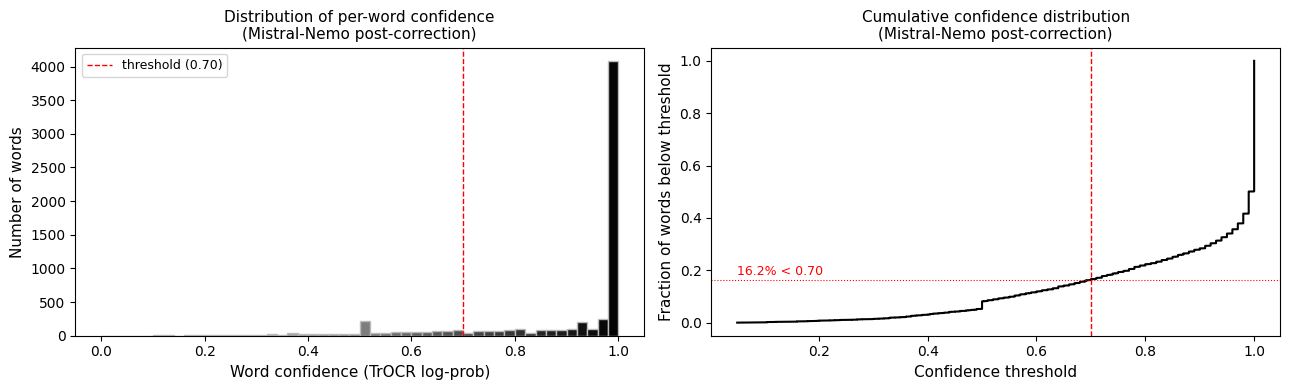

Histogram saved: /Users/hedyeh/Ginger_Gradient/Capstone-Project/data/mistral_confidence_distribution.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

if not all_confs:
    print('No confidence values collected.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── Left: histogram ───────────────────────────────────────────────
    ax   = axes[0]
    bins = np.linspace(0, 1, 51)
    n, _, patches = ax.hist(all_confs, bins=bins, edgecolor='none')
    bin_centres   = 0.5 * (bins[:-1] + bins[1:])
    for patch, bc in zip(patches, bin_centres):
        g = 1.0 - bc
        patch.set_facecolor((g, g, g))
        patch.set_edgecolor('#bbbbbb')

    ax.set_xlabel('Word confidence (TrOCR log-prob)', fontsize=11)
    ax.set_ylabel('Number of words', fontsize=11)
    ax.set_title('Distribution of per-word confidence\n(Mistral-Nemo post-correction)', fontsize=11)
    ax.axvline(0.70, color='red', linestyle='--', linewidth=1, label='threshold (0.70)')
    ax.legend(fontsize=9)

    # ── Right: cumulative ─────────────────────────────────────────────
    ax2      = axes[1]
    sorted_c = np.sort(all_confs)
    ax2.plot(sorted_c, np.linspace(0, 1, len(sorted_c)), color='black', linewidth=1.5)
    ax2.axvline(0.70, color='red', linestyle='--', linewidth=1)
    frac_below = np.mean(np.array(all_confs) < 0.70)
    ax2.axhline(frac_below, color='red', linestyle=':', linewidth=0.8)
    ax2.set_xlabel('Confidence threshold', fontsize=11)
    ax2.set_ylabel('Fraction of words below threshold', fontsize=11)
    ax2.set_title('Cumulative confidence distribution\n(Mistral-Nemo post-correction)', fontsize=11)
    ax2.text(0.05, frac_below + 0.02, f'{frac_below*100:.1f}% < 0.70',
             fontsize=9, color='red')

    plt.tight_layout()
    plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Histogram saved: {OUTPUT_PNG}')

## Output

| File | Description |
|---|---|
| `data/mistral_confidence_coloured_text.html` | Full document, hover for exact score |
| `data/mistral_confidence_distribution.png` | Histogram + CDF of confidence scores |
| `data/mistral_corrected_transcriptions/*.txt` | One corrected page per file |

**Comparing with Alex's Qwen output:**
- Open both HTML files side by side in a browser
- **Black words** → TrOCR was highly confident → likely correct in both
- **Teal-blue words** (this file) → corrected by Mistral-Nemo
- **Green words** (Alex's file) → corrected by Qwen
- Pages where the two methods disagree on corrections are the most interesting to review

## Summary and concluding remarks

Mistral making things worse

- Continuation of a journal → Continuation of a Journal: trivial capitalisation change, not an OCR error
- of a Voyage → Of a voyage ✗ wrongly lowercases "Voyage" which Forster capitalised intentionally
- from ulcatea → from Ulcelet ✗ this is bad — ulcatea is Forster's spelling of Uliatea (a Polynesian island), Mistral changed it to a completely wrong word
- in New Zealand → In New Zealand ✗ trivial capitalisation, not an error
- in the society sides. → In the society's sides. ✗ adds apostrophe that may not belong


### The 27% replacement rate now makes sense: Mistral is overcorrecting, making many trivial capitalisation changes that count as replacements but add no value, and in some cases actively worsening the text (place names, archaic spellings).